<a href="https://colab.research.google.com/github/RecursionAndIteration/AIcourse/blob/main/Kopia_notatnika_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

In [ ]:
df = sns.load_dataset("titanic")

print(df.head(10))
print(df.isnull().sum())
print("\n liczba pasażerów z nullem")
df = df.dropna(subset=['age'])
print (df.isnull().sum())
print(df)
print(len(df))


   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

In [ ]:
def categorise_fare(fare, fare_ranges):
  if fare <= fare_ranges[0]:
    return 0
  elif fare <= fare_ranges[1]:
    return 1
  else:
    return 2

min_fare = df['fare'].min()
max_fare = df['fare'].max()
fare_step = (max_fare - min_fare) / 3
fare_ranges = [min_fare + fare_step, min_fare + 2 * fare_step]
print("\n przedziały cen biletów")
print(f"\n niska: {min_fare} -  {fare_ranges[0]}")
print(f"\n średnia: {fare_ranges[0]} - {fare_ranges[1]}")
print(f"\n wysoka: {fare_ranges[1]} - {max_fare}")


 przedziały cen biletów

 niska: 0.0 -  170.7764

 średnia: 170.7764 - 341.5528

 wysoka: 341.5528 - 512.3292


In [ ]:
#69
selected_features = ['sex','pclass','age','fare_category']
df_model = df.copy()
df_model['sex'] = df_model['sex'].map({'male':0,'female':1})
df_model['fare_category'] = df_model['fare'].apply(lambda x: categorise_fare(x, fare_ranges))


In [ ]:
#HALF LIFE 3 TOMMOROW
x = df_model[selected_features]
y = df_model['survived']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Sekcja 6
model = LogisticRegression(
    random_state=42,
    C=0.2

)

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred)



print("\nWynik modelu")
print(f"dokładność modelu: {accuracy: .3f}")


Wynik modelu
dokładność modelu:  0.741


In [ ]:
#sekcja 7
print("\n Raport Klasyfikacji:")

print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
precision = tp / (tp+fp)
f1 =  2*precision* sensitivity / (precision + sensitivity)


print(f"\ndodatkowe metryki")
print(f"czułość (recall) : {sensitivity: .3f}")
print(f"precyzja: {precision: .3f}")
print(f"F1 score: {f1: .3f}")


 Raport Klasyfikacji:
              precision    recall  f1-score   support

           0       0.78      0.79      0.79        87
           1       0.67      0.66      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143


dodatkowe metryki
czułość (recall) :  0.661
precyzja:  0.673
F1 score:  0.667


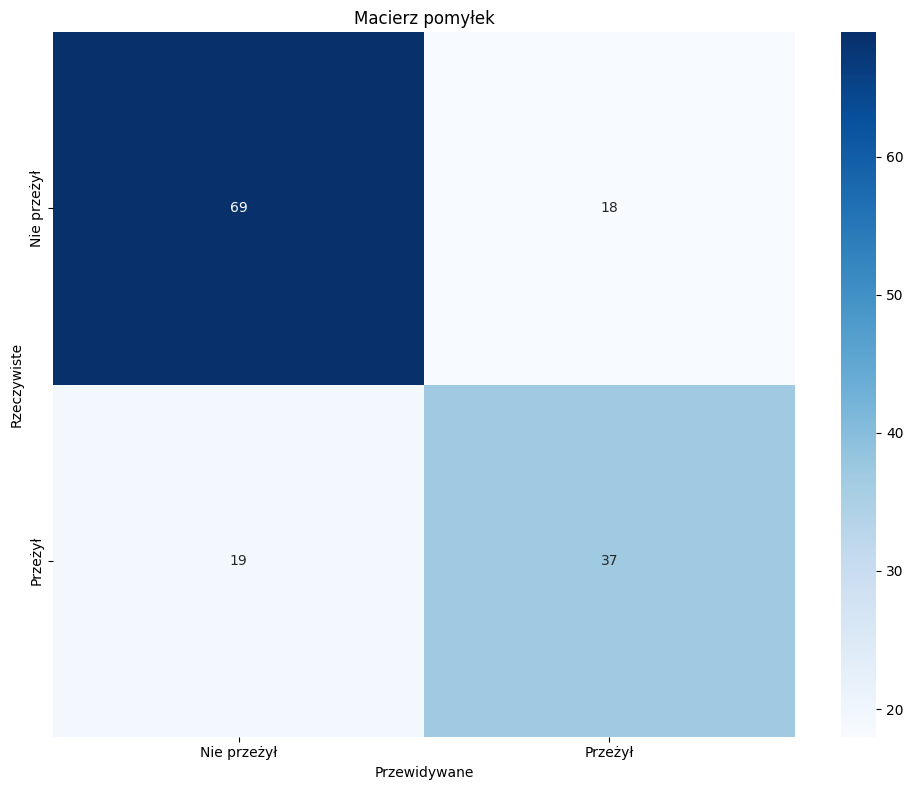

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Nie przeżył','Przeżył'],
            yticklabels=['Nie przeżył','Przeżył'])
plt.title('Macierz pomyłek')
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.tight_layout()
plt.show()

In [ ]:
# Sekcja 9


while True:
  print("\nPrognoza przeżycia dla nowego pasażera")
  print("(Wpisz koniec by zakończyć)")

  try:
    sex_input = input("\n Podaj płeć (m/k): ").lower()
    if sex_input == 'koniec':
      break
    sex=1 if sex_input == 'k' else 0

    pclass_input = input("Podaj klase (1/2/3): ")
    if pclass_input == 'koniec':
      break
    pclass = int(pclass_input)

    age_input = input("Podaj wiek: ")
    if age_input == 'koniec':
      break
    age = float(age_input)

    print(f"\n Przedziały cen biletów:")
    print(f"0 - niska: {min_fare: .2f} - {fare_ranges[0]: .2f}")
    print(f"1 - średnia: {fare_ranges[0]: .2f} - {fare_ranges[1]: .2f}")
    print(f"2 - wysoka: {fare_ranges[1]: .2f} - {max_fare: .2f}")

    fare_category_input = input("Podaj przedział cenowy (0/1/2): ")
    if fare_category_input == 'koniec':
      break
    fare_category = int(fare_category_input)
    new_passenger = pd.DataFrame({
        'sex': [sex],
        'pclass': [pclass],
        'age': [age],
        'fare_category': [fare_category]
    })

    new_passenger_scaled = scaler.transform(new_passenger)
    prediction = model.predict(new_passenger_scaled)
    probability = model.predict_proba(new_passenger_scaled)

    print("\n Wynik prognozy:")
    print(f"płeć: {'Kobieta' if sex==1 else 'Mężczyzna'}")
    print(f"klasa: {pclass}")
    print(f"wiek: {age}")
    print(f"Kategoria cenowa{'Niska' if fare_category==0 else 'Średnia' if fare_category==1 else 'Wysoka'}")
    print(f"Przewidywanie przeżycia: {'Tak' if prediction[0]==1 else 'Nie'}")
    print(f"Prawdopodobieństwo przeżycia: {probability[0][1]: .2f}")

  except ValueError:
    print("\n Błąd wprowadź poprawnie dane tłumoku")
  except Exception as e:
    print(f"Wystąpił błąd {e}")
  if input("\n Czy chcesz sprawzić kolejnego pasażera? (t/n) : ").lower() != 't':
    break
print("\n Koniec Programu")



Prognoza przeżycia dla nowego pasażera
(Wpisz koniec by zakończyć)


KeyboardInterrupt: Interrupted by user